In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Coffee Shop Sales.csv")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## Check missing vakues

In [3]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

## transaction_date to datetime
## Calculate total sales

In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%d-%m-%Y')
df["total_sales"] = df["transaction_qty"] * df["unit_price"]



##  Histograms for numerical attributesshow()


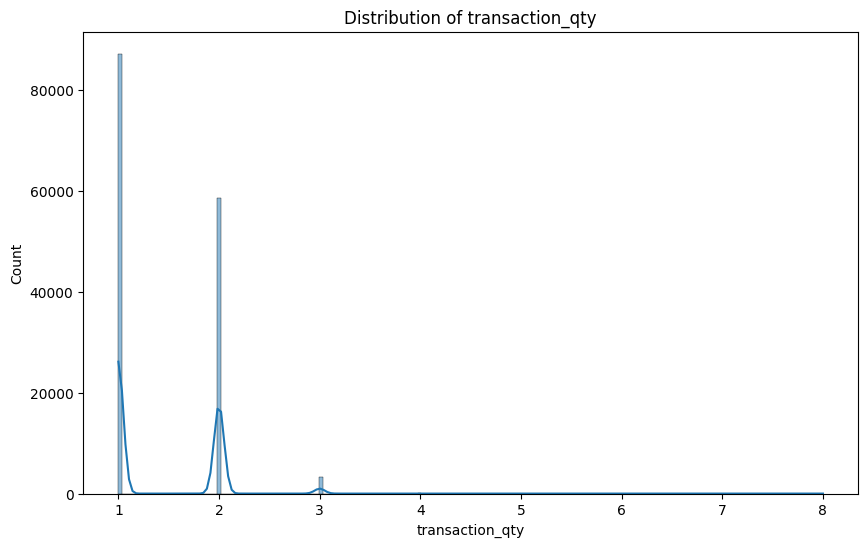

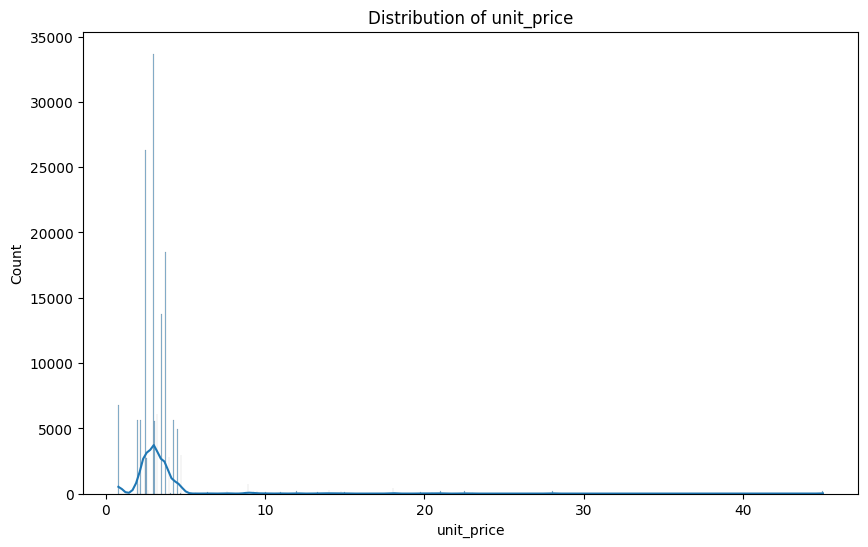

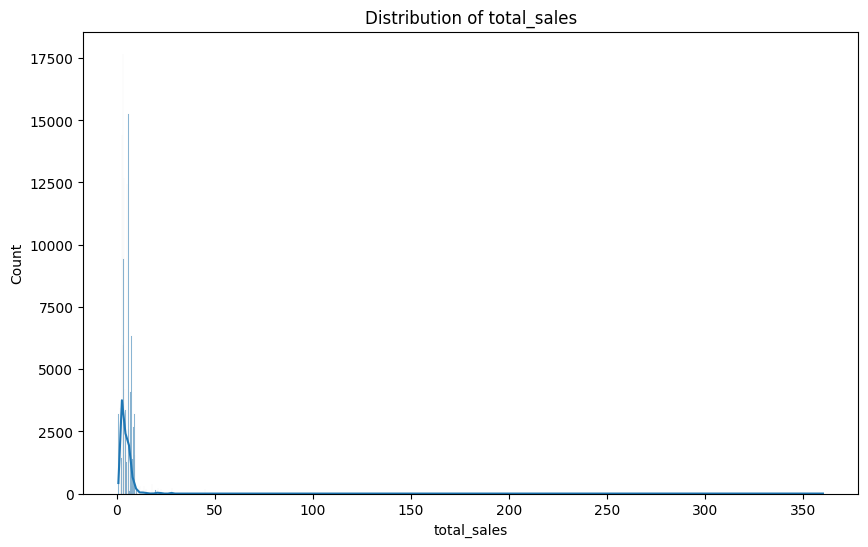

In [4]:
numerical_cols = ['transaction_qty', 'unit_price', 'total_sales']  # Update with relevant numerical columns
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


## Check for outliers in total_sales

In [6]:
# Total bill statistics

print(df["total_sales"].describe())

count    149116.000000
mean          4.686367
std           4.227099
min           0.800000
25%           3.000000
50%           3.750000
75%           6.000000
max         360.000000
Name: total_sales, dtype: float64


## Total_sales distribution

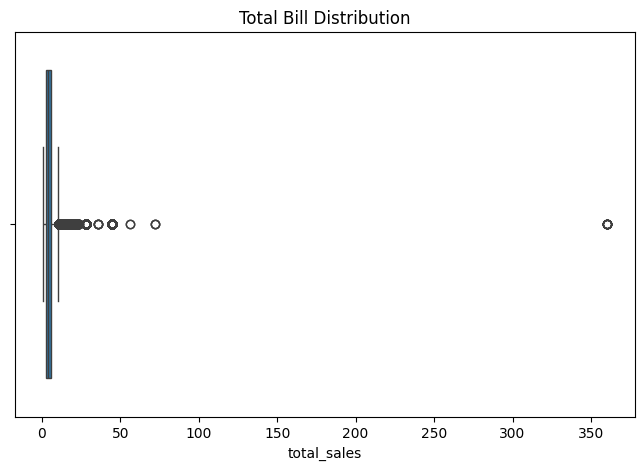

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["total_sales"])
plt.title("Total Bill Distribution")
plt.show()

## Top-Selling Stores or Products

In [6]:
# Revenue by store
store_revenue = df.groupby("store_location")["total_sales"].sum().reset_index().sort_values(by="total_sales", ascending=False)
print(store_revenue)

# Revenue by product category
category_revenue = df.groupby("product_category")["total_sales"].sum().reset_index().sort_values(by="total_sales", ascending=False)
print(category_revenue)


    store_location  total_sales
1   Hell's Kitchen    236511.17
0          Astoria    232243.91
2  Lower Manhattan    230057.25
     product_category  total_sales
2              Coffee    269952.45
8                 Tea    196405.95
0              Bakery     82315.64
4  Drinking Chocolate     72416.00
3        Coffee beans     40085.25
1             Branded     13607.00
6           Loose Tea     11213.60
5            Flavours      8408.80
7  Packaged Chocolate      4407.64


## Extract month and day info

In [9]:
# Extract month, week, and day of the week
df["month"] = df["transaction_date"].dt.month
df["week"] = df["transaction_date"].dt.isocalendar().week
df["day_of_week"] = df["transaction_date"].dt.day_name()


## Monthly sales trend

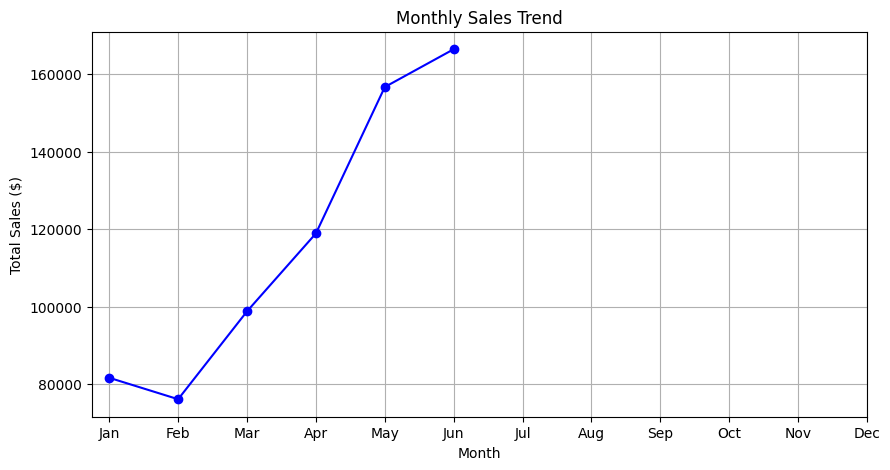

In [10]:
import matplotlib.pyplot as plt

# Aggregate total sales per month
monthly_sales = df.groupby("month")["total_sales"].sum().reset_index()

# Plot monthly sales trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["month"], monthly_sales["total_sales"], marker="o", linestyle="-", color="blue")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()

## Hourly sales pattern

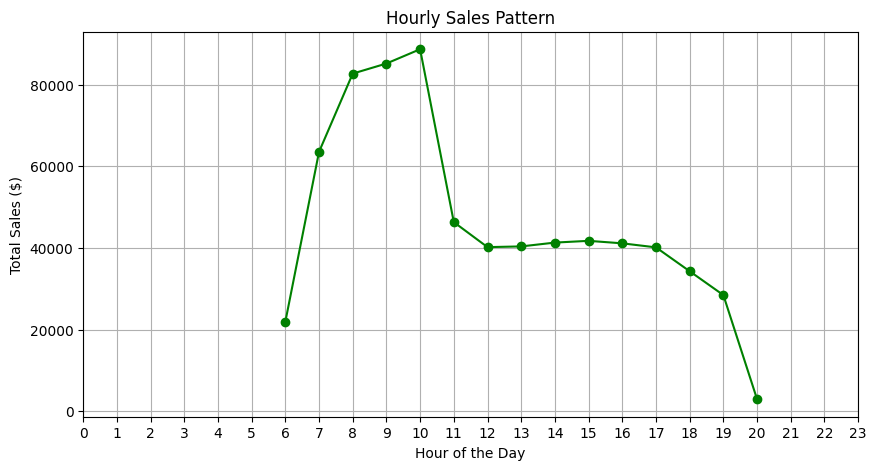

In [11]:
# Extract hour from transaction_time
df["hour"] = pd.to_datetime(df["transaction_time"], format="%H:%M:%S").dt.hour

# Aggregate total sales per hour
hourly_sales = df.groupby("hour")["total_sales"].sum().reset_index()

# Plot hourly sales trend
plt.figure(figsize=(10, 5))
plt.plot(hourly_sales["hour"], hourly_sales["total_sales"], marker="o", linestyle="-", color="green")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Sales ($)")
plt.title("Hourly Sales Pattern")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


## Best-Selling Products by Season

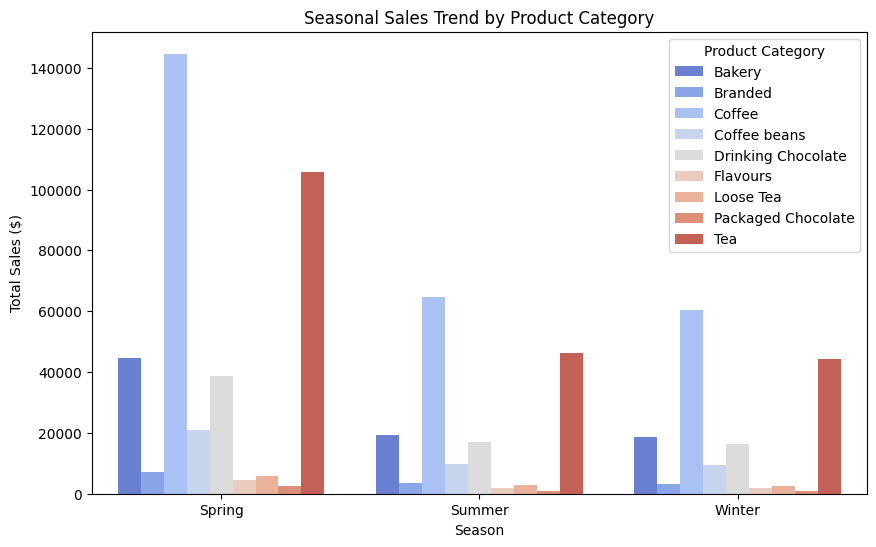

In [12]:
# Define seasons
season_mapping = {1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer",
                  7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"}

df["season"] = df["month"].map(season_mapping)

# Aggregate total sales per product and season
seasonal_sales = df.groupby(["season", "product_category"])["total_sales"].sum().reset_index()

# Plot seasonal trends
plt.figure(figsize=(10, 6))
sns.barplot(x="season", y="total_sales", hue="product_category", data=seasonal_sales, palette="coolwarm")
plt.xlabel("Season")
plt.ylabel("Total Sales ($)")
plt.title("Seasonal Sales Trend by Product Category")
plt.legend(title="Product Category", bbox_to_anchor=(1,1))
plt.show()


## Sales by Day of the Week for Each Product Category

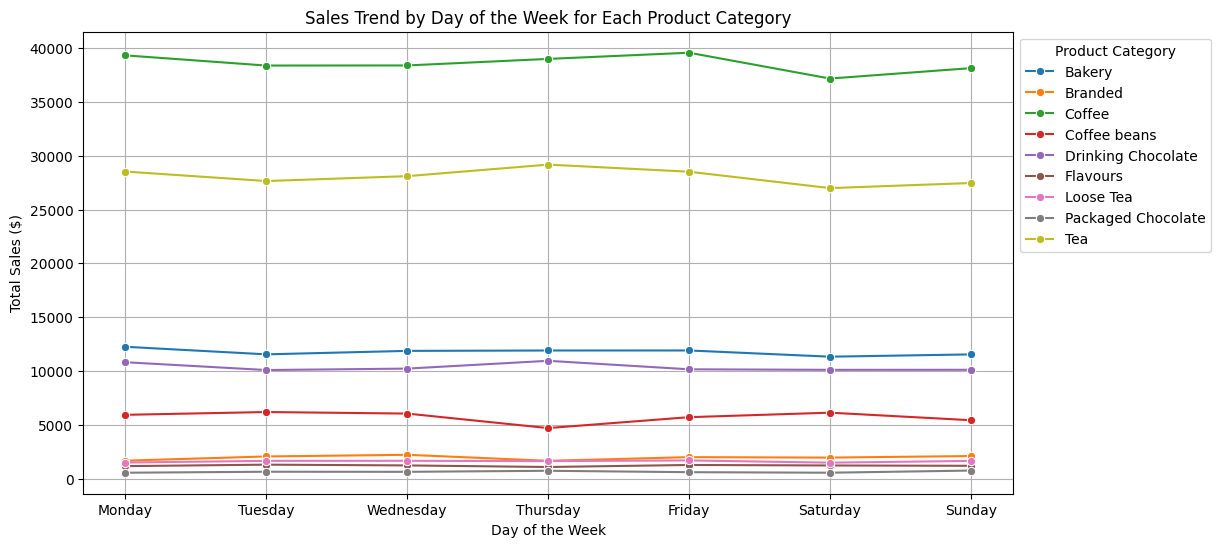

In [13]:
# Aggregate total sales by product category and day of the week
weekday_sales = df.groupby(["day_of_week", "product_category"])["total_sales"].sum().reset_index()

# Order days correctly
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales["day_of_week"] = pd.Categorical(weekday_sales["day_of_week"], categories=weekday_order, ordered=True)

# Plot sales by day of the week for each product category
plt.figure(figsize=(12, 6))
sns.lineplot(x="day_of_week", y="total_sales", hue="product_category", data=weekday_sales, marker="o", palette="tab10")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales ($)")
plt.title("Sales Trend by Day of the Week for Each Product Category")
plt.grid(True)
plt.legend(title="Product Category", bbox_to_anchor=(1,1))
plt.show()


In [14]:
daily_hourly_summary = df.groupby(['day_of_week', 'hour'])\
    .agg({'total_sales': ['count', 'sum', 'mean']}).reset_index()
daily_hourly_summary.head()

day_of_week hour total_sales                    
                         count       sum      mean
0      Friday    6         707   3385.73  4.788868
1      Friday    7        1989   9386.04  4.718974
2      Friday    8        2544  11746.65  4.617394
3      Friday    9        2707  12750.00  4.710011
4      Friday   10        2761  13155.66  4.764817

# Bivariate
# daily revenue and quantity

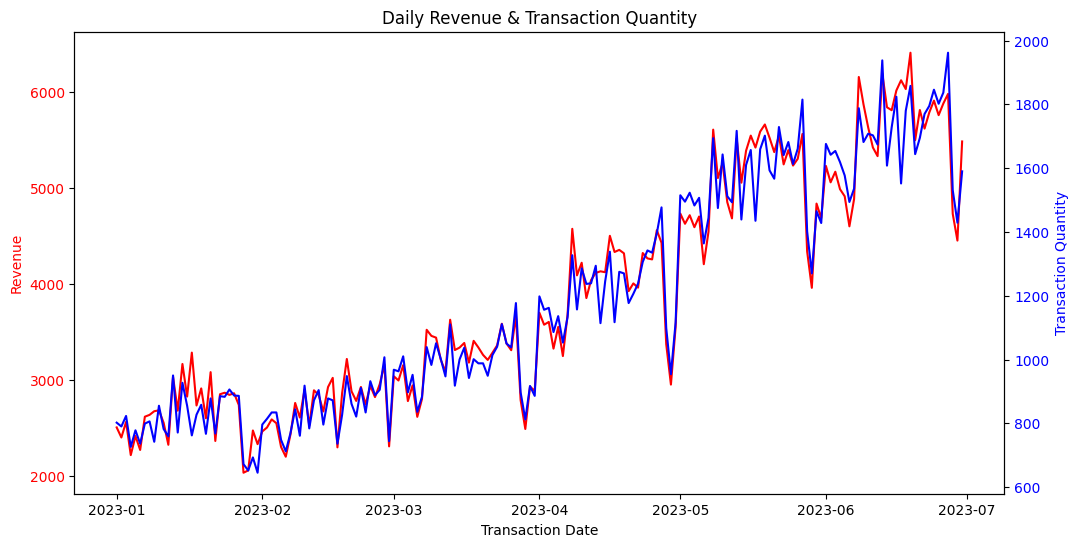

In [7]:
# daily revenue and quantity
daily_revenue = df.groupby('transaction_date')['total_sales'].sum().reset_index()
daily_qty = df.groupby('transaction_date')['transaction_qty'].sum().reset_index()


import matplotlib.pyplot as plt

fig, ax0 = plt.subplots(figsize=(12, 6))  # Create figure and primary axis

# Create a second y-axis sharing the same x-axis
ax1 = ax0.twinx()

# Plot Revenue on primary axis (left y-axis)
ax0.plot(daily_revenue['transaction_date'], daily_revenue['total_sales'], color='red', label='Revenue')
ax0.set_ylabel('Revenue', color='red')
ax0.tick_params(axis='y', labelcolor='red')

# Plot Transaction Quantity on secondary axis (right y-axis)
ax1.plot(daily_qty['transaction_date'], daily_qty['transaction_qty'], color='blue', label='Transaction Quantity')
ax1.set_ylabel('Transaction Quantity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Set common x-axis label and title
ax0.set_xlabel('Transaction Date')
ax0.set_title('Daily Revenue & Transaction Quantity')

# Show the plot
plt.show()


## Multivariate

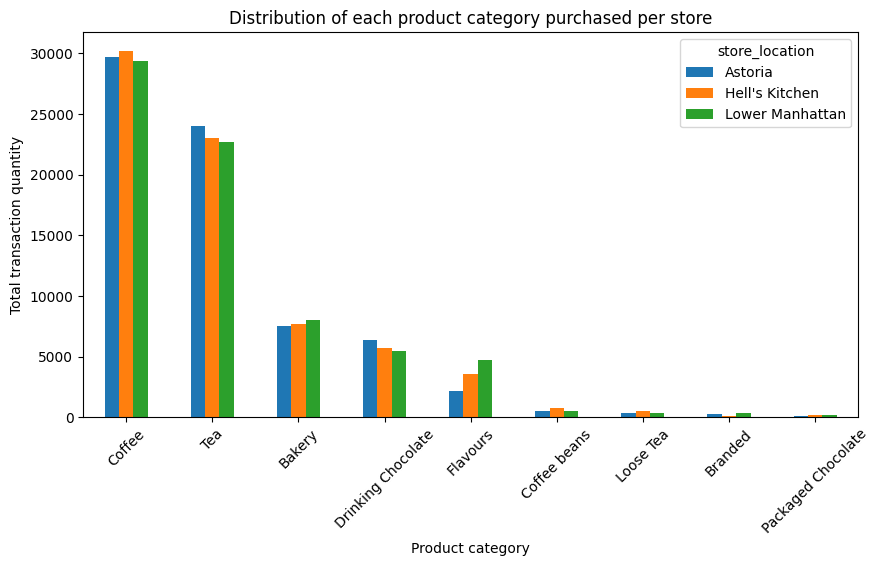

In [16]:
pivoted = df.pivot_table(index = 'product_category', columns='store_location', values='transaction_qty', aggfunc = 'sum')
pivoted['Total'] =  pivoted.sum(axis = 1)
pivoted.sort_values(by='Total', ascending = False, inplace = True)
pivoted.drop(columns = ['Total'], inplace = True)

pivoted.plot(kind='bar', figsize = (10,5))
plt.xticks(rotation = 45)
plt.xlabel('Product category')
plt.ylabel('Total transaction quantity')
plt.title('Distribution of each product category purchased per store')
plt.show()

## Profit loss analysis

In [8]:
!pip install pyspark
from pyspark.sql import SparkSession

In [9]:
!pip install prophet
!pip install pystan
!pip install plotly

  Using cached pystan-3.10.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Using cached pystan-3.9.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.9.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.8.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pystan-3.7.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.6.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.5.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.4.0-py3-none-any.whl.metadata (3.7 kB)
INFO: pip is still looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Using cached pystan-3.3.0-py3-none-any.whl.metadata (3.6 kB)
  Using cached pystan-3.2.0-py3-none-any.whl.metadata (3.6 kB)
  Using ca

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "C:\Users\vijay\AppData\Local\Temp\pip-install-yc0sl613\pystan_dca6792bdfbc41fc8c1d025ea11c8980\setup.py", line 122, in <module>
          from Cython.Build.Inline import _get_build_extension
      ModuleNotFoundError: No module named 'Cython'
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Prophet

In [10]:
from prophet import Prophet
from prophet.plot import plot_plotly
import plotly.offline as py
import numpy as np
from prophet.diagnostics import cross_validation, performance_metrics

c:\Users\vijay\OneDrive\Documents\AIDI2005-capstone 2\Capstone-2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,total_sales,y
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,1.791759,1.791759
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1.824549,1.824549
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2.197225,2.197225
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,0.693147,0.693147
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,1.824549,1.824549
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,1.609438,1.609438
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,1.791759,1.791759
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,1.098612,1.098612
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,1.321756,1.321756


In [11]:
# Calculate total sales for each transaction
df['total_sales'] = df['transaction_qty'] * df['unit_price']

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%d-%m-%Y')

# Aggregate sales by day
daily_sales = df.groupby('transaction_date')['total_sales'].sum().reset_index()
daily_sales = daily_sales.set_index('transaction_date')

# Display the processed data
print(daily_sales.head())

                  total_sales
transaction_date             
2023-01-01            2508.20
2023-01-02            2403.35
2023-01-03            2565.00
2023-01-04            2220.10
2023-01-05            2418.85


In [12]:
# Create time-based features
def create_features(df):
    df = df.copy()
    df['day'] = df.index.day
    df['month'] = df.index.month
    df["quarter"] = df.index.quarter
    df['day_of_week'] = df.index.dayofweek
    df['day_of_year'] = df.index.dayofyear
    df['week_of_year'] = df.index.isocalendar().week
    return df

daily_sales = create_features(daily_sales)

In [13]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype


In [15]:
daily_sales

,total_sales,day,month,quarter,day_of_week,day_of_year,week_of_year
transaction_date,,,,,,,
2023-01-01,2508.20,1,1,1,6,1,52
2023-01-02,2403.35,2,1,1,0,2,1
2023-01-03,2565.00,3,1,1,1,3,1
2023-01-04,2220.10,4,1,1,2,4,1
2023-01-05,2418.85,5,1,1,3,5,1
...,...,...,...,...,...,...,...
2023-06-26,5875.90,26,6,2,0,177,26
2023-06-27,5975.65,27,6,2,1,178,26
2023-06-28,4728.90,28,6,2,2,179,26


In [49]:
df_pivot

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
transaction_date,,,,,,,,,
2023-01-01,290250.834393,NaN,1.028683e+06,NaN,213419.731172,NaN,NaN,NaN,8.152634e+05
2023-01-02,371350.332239,NaN,1.075635e+06,NaN,162198.995690,NaN,NaN,NaN,8.067266e+05
2023-01-03,345739.964498,NaN,1.020146e+06,NaN,230493.309665,NaN,NaN,NaN,8.878261e+05
2023-01-04,260372.072029,NaN,9.475836e+05,NaN,183540.968808,NaN,NaN,NaN,7.298955e+05
2023-01-05,311592.807511,NaN,9.988043e+05,NaN,204882.941925,NaN,NaN,NaN,8.195318e+05
...,...,...,...,...,...,...,...,...,...
2023-06-26,742700.664477,8531.732644,2.147002e+06,8517.399438,371350.332239,106752.537521,46952.340858,8536.789247,1.536622e+06
2023-06-27,712821.902113,12801.812802,2.202492e+06,4258.048015,448181.435460,149472.043701,8536.789247,8536.789247,1.732968e+06
2023-06-28,627454.009645,NaN,2.100050e+06,NaN,375618.726862,NaN,NaN,NaN,1.464059e+06


In [16]:
# Split into train and test sets (last 30 days for testing)
df_train = daily_sales.iloc[:-30]
df_test = daily_sales.iloc[-30:]

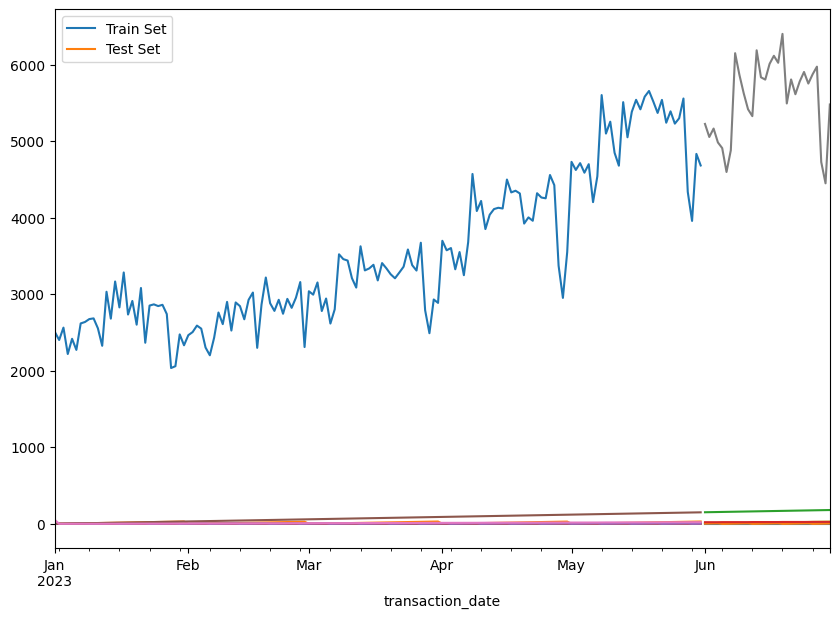

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
df_train.plot(ax=ax, label="Training Set")
df_test.plot(ax=ax, label="Test Set")
ax.legend(["Train Set", "Test Set"])
plt.show()

In [19]:
df_train

,total_sales,day,month,quarter,day_of_week,day_of_year,week_of_year
transaction_date,,,,,,,
2023-01-01,2508.20,1,1,1,6,1,52
2023-01-02,2403.35,2,1,1,0,2,1
2023-01-03,2565.00,3,1,1,1,3,1
2023-01-04,2220.10,4,1,1,2,4,1
2023-01-05,2418.85,5,1,1,3,5,1
...,...,...,...,...,...,...,...
2023-05-27,5559.15,27,5,2,5,147,21
2023-05-28,4338.65,28,5,2,6,148,21
2023-05-29,3959.50,29,5,2,0,149,22


In [20]:
# Sum all product categories into a single 'y' column
df_train_prophet = df_train.reset_index()
df_train_prophet['y'] = df_train_prophet.iloc[:, 1:].sum(axis=1)  # Sum all columns except 'ds'
df_train_prophet = df_train_prophet.rename(columns={'transaction_date': 'ds'})[['ds', 'y']]


In [21]:
from prophet import Prophet
from prophet.plot import plot_plotly
import plotly.offline as py
import numpy as np
from prophet.diagnostics import cross_validation, performance_metrics

In [22]:
# Select the "Bakery" column and prepare the dataframe
##df_bakery_prophet = df_train_prophet[['ds', 'Bakery']].rename(columns={'Bakery': 'y'})

# Ensure that your dataframe only contains the required columns: 'ds' and 'y'
df_train_prophet = df_train_prophet[['ds', 'y']]
# Ensure the 'ds' column is in datetime format (if it's not already)
df_train_prophet['ds'] = pd.to_datetime(df_train_prophet['ds'])
# Now check if the dataframe has the correct columns
print(df_train_prophet.head())

# Initialize the Prophet model
#model = Prophet(changepoint_prior_scale=0.01,seasonality_prior_scale=10,n_changepoints=15,seasonality_mode='multiplicative')
#model.add_seasonality(name='weekly', period=7, fourier_order=6)
model = Prophet(changepoint_prior_scale=0.00002, seasonality_prior_scale=2, n_changepoints=15, seasonality_mode='additive')

# Add specific seasonalities
model.add_seasonality(name='weekly', period=7, fourier_order=6)
# Fit the model
model.fit(df_train_prophet)




          ds        y
0 2023-01-01   2570.2
1 2023-01-02  2410.35
2 2023-01-03   2575.0
3 2023-01-04   2233.1
4 2023-01-05  2434.85


09:19:26 - cmdstanpy - INFO - Chain [1] start processing
09:19:26 - cmdstanpy - INFO - Chain [1] done processing
09:19:26 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
09:19:26 - cmdstanpy - INFO - Chain [1] start processing
09:19:27 - cmdstanpy - INFO - Chain [1] done processing


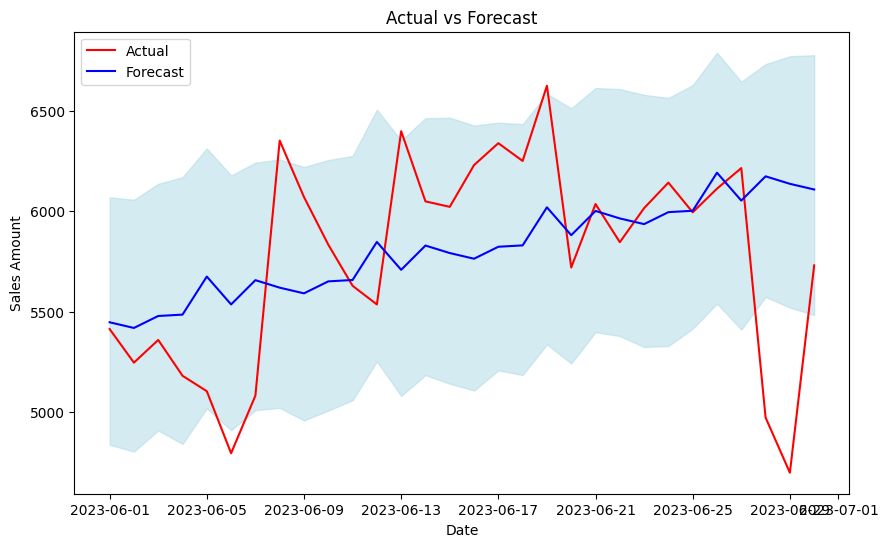

In [24]:
# Predict on test set with model
## df_test_prophet = df_test.reset_index() \
##    .rename(columns={'transaction_date':'ds',
##                     'Bakery':'y'})
df_test_prophet = df_test.reset_index()
df_test_prophet['y'] = df_test_prophet.iloc[:, 1:].sum(axis=1)  # Sum all columns except 'ds'
df_test_prophet = df_test_prophet.rename(columns={'transaction_date': 'ds'})[['ds', 'y']]
df_test_future = model.make_future_dataframe(periods=30)
df_test_fcst = model.predict(df_test_future)
df_test_pred = df_test_fcst[df_test_fcst['ds'] > df_train_prophet['ds'].max()]
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual values
ax.plot(df_test_prophet['ds'], df_test_prophet['y'], label='Actual', color='red')

# Plot forecasted values
ax.plot(df_test_pred['ds'], df_test_pred['yhat'], label='Forecast', color='blue')

# Uncertainty interval
ax.fill_between(df_test_pred['ds'], df_test_pred['yhat_lower'], df_test_pred['yhat_upper'], color='lightblue', alpha=0.5)

ax.set_title("Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales Amount")
ax.legend()

plt.show()


In [40]:
df_test_fcst[['ds','trend','yhat_lower','yhat_upper','additive_terms','weekly','weekly_lower','weekly_upper','yhat']]

,ds,trend,yhat_lower,yhat_upper,additive_terms,weekly,weekly_lower,weekly_upper,yhat
0,2023-01-01,1731.307943,1057.701018,2336.751409,-42.972117,-42.972117,-42.972117,-42.972117,1688.335826
1,2023-01-02,1755.961313,1236.849232,2508.784499,122.120764,122.120764,122.120764,122.120764,1878.082077
2,2023-01-03,1780.614682,1073.596993,2327.457157,-41.446072,-41.446072,-41.446072,-41.446072,1739.168610
3,2023-01-04,1805.268052,1274.762559,2498.750498,54.815058,54.815058,54.815058,54.815058,1860.083110
4,2023-01-05,1829.921421,1211.030149,2500.322458,-7.190435,-7.190435,-7.190435,-7.190435,1822.730987
...,...,...,...,...,...,...,...,...,...
176,2023-06-26,6070.300979,5539.902544,6790.609756,122.120764,122.120764,122.120764,122.120764,6192.421743
177,2023-06-27,6094.954348,5410.337999,6645.843448,-41.446072,-41.446072,-41.446072,-41.446072,6053.508276
178,2023-06-28,6119.607718,5572.615104,6733.661885,54.815058,54.815058,54.815058,54.815058,6174.422776
179,2023-06-29,6144.261087,5520.254223,6772.703205,-7.190435,-7.190435,-7.190435,-7.190435,6137.070653


## Actual vs Forecasted

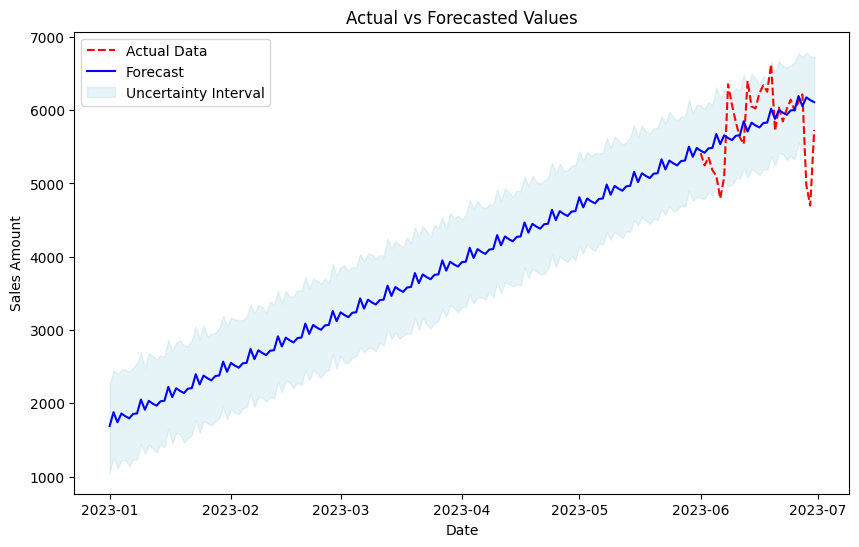

In [69]:
# Filter forecast data to remove training period
## df_test_fcst = df_test_fcst[df_test_fcst['ds'] > df_train_prophet['ds'].max()]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(df_test.index, df_test.sum(axis=1), label="Actual Data", color='red', linestyle='dashed')

# Plot the forecasted values from Prophet
ax.plot(df_test_fcst['ds'], df_test_fcst['yhat'], label="Forecast", color='blue')

# Add uncertainty interval (optional)
ax.fill_between(df_test_fcst['ds'], df_test_fcst['yhat_lower'], df_test_fcst['yhat_upper'], 
                color='lightblue', alpha=0.3, label="Uncertainty Interval")

# Set title and labels
ax.set_title('Actual vs Forecasted Values')
ax.set_xlabel('Date')
ax.set_ylabel('Sales Amount')



# Show legend
ax.legend()

# Display the plot
plt.show()


## Metrics

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score,mean_absolute_percentage_error
import numpy as np
# Actual vs Predicted values
y_actual = df_test_prophet['y']
y_pred = df_test_pred['yhat']
mse = mean_squared_error(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((df_test_prophet['y'].values - df_test_pred['yhat'].values) / df_test_prophet['y'].values))
smape = np.mean(2 * np.abs(y_actual - y_pred) / (np.abs(y_actual) + np.abs(y_pred))) * 100
r2 = r2_score(y_actual,y_pred)
rmse = np.sqrt(mse)

# Print results
#print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2}")
print(f"MAPE: {mape:.2f}%")
## print(f"SMAPE: {smape:.2f}%")

MAE: 374.02
RMSE: 503.99
R-squared: 0.01991019485296308
MAPE: 0.07%


In [ ]:
## Prediction

23:31:27 - cmdstanpy - INFO - Chain [1] start processing
23:31:27 - cmdstanpy - INFO - Chain [1] done processing


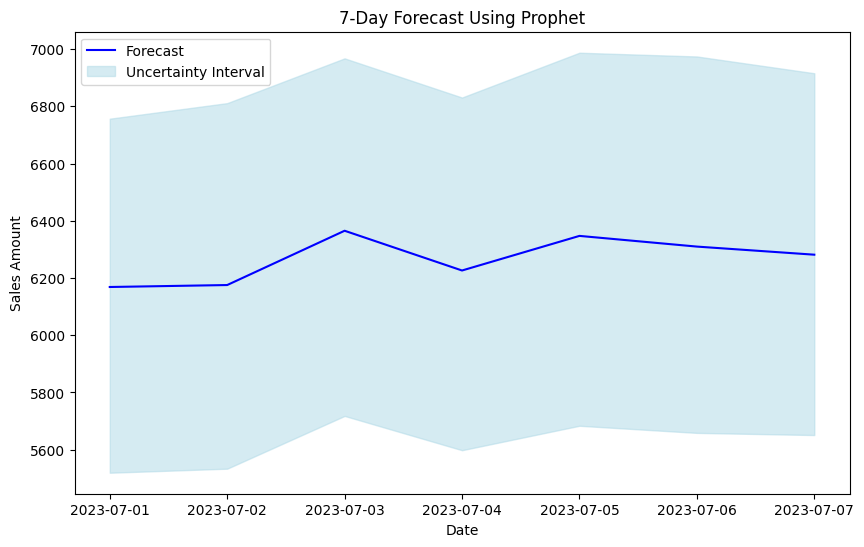

In [71]:
m = Prophet(daily_seasonality=True)
m.fit(df_test_prophet)
# Predict the future 7 days
future = m.make_future_dataframe(periods=7)
forecast_7_days = model.predict(future)

# Filter only the new 7 days
forecast_next_week = forecast_7_days[forecast_7_days['ds'] > df_test_prophet['ds'].max()]

# Display the forecast
#print(forecast_next_week[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

# 📊 Plot the forecast
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
#ax.plot(df_test_fcst.index, df_test_fcst.sum(axis=1), label="Actual Data", color='red', linestyle='dashed')
ax.plot(forecast_next_week['ds'], forecast_next_week['yhat'], label='Forecast', color='blue')
ax.fill_between(forecast_next_week['ds'], forecast_next_week['yhat_lower'], forecast_next_week['yhat_upper'], 
                color='lightblue', alpha=0.5, label='Uncertainty Interval')

ax.set_title('7-Day Forecast Using Prophet')
ax.set_xlabel('Date')
ax.set_ylabel("Sales Amount")
ax.legend()

plt.show()


In [74]:
df_test_fcst = df_test_fcst[['ds', 'yhat']]
df_test_fcst.to_csv('forecast_results_Sales.csv', index=False)
